In [7]:
import flappy_bird_env  # noqa
import numpy as np
import cv2
# Note: For render_mode="human", we don't need headless setup
# pygame will initialize automatically when creating the environment

import gymnasium as gym
from memory_system import MemoryConfig, MemoryBank, MemoryType
from instruction_set import InstructionSet
from operation import ALL_OPS, SCALAR_OPS, AUTOML_ALL_OPS, CV_ALL_OPS
from individual import Individual
from population import Population, PopulationConfig
from operators import GeneticOperators
from evaluator import CartPoleEvaluator, FlappyBirdEvaluator, FlappyBirdEvaluatorConfig
from evolution_engine import EvolutionEngine, EvolutionConfig


In [8]:
# Setup for FlappyBird with patch-based image observations
rng = np.random.default_rng(0)

# Memory configuration for FlappyBird
# We need matrix observation registers to 
# store image patches
# Default patch size is 72x72, and we extract 8 patches
patch_size = 700
num_patches = 700

memory_cfg = MemoryConfig(
    n_scalar=8,          # Working scalars (for computation)
    n_vector=8,          # Working vectors
    n_matrix=8,          # Working matrices (for CV operations)
    n_obs_scalar=0,      # No scalar observations (using matrices instead)
    n_obs_vector=0,      # No vector observations
    n_obs_matrix=1,  # 8 matrix observation registers for patches
    vector_size=200,
    matrix_shape=(patch_size, patch_size),  # Each patch is 72x72
)

# Use AutoML + CV operations for image processing
# CV operations work on matrices (our patches)
# AutoML operations handle the logic/decision making
all_ops = AUTOML_ALL_OPS + CV_ALL_OPS
instruction_set = InstructionSet([op() for op in all_ops], memory_cfg)
operators = GeneticOperators(instruction_set, rng)

print(f"Memory config: {memory_cfg}")
print(f"Total operations: {len(all_ops)}")
print(f"  - AutoML operations: {len(AUTOML_ALL_OPS)}")
print(f"  - CV operations: {len(CV_ALL_OPS)}")


Memory config: MemoryConfig(n_scalar=8, n_vector=8, n_matrix=8, n_obs_scalar=0, n_obs_vector=0, n_obs_matrix=1, vector_size=200, matrix_shape=(700, 700), init_scalar_range=(-2.0, 2.0), init_vector_range=(-1.0, 1.0), init_matrix_range=(-0.5, 0.5))
Total operations: 77
  - AutoML operations: 64
  - CV operations: 13


In [23]:
# Create FlappyBird evaluator with quantized image processing
evaluator_config = FlappyBirdEvaluatorConfig(
    env_id="FlappyBird-v0",
    episodes=3,  # Test with 3 episodes
    max_steps=500,
    output_register=7,  # Read action from scalar register 7
    render_mode="human",  # Watch the game
    rng_seed=0,  # Use seed 0 (matching rng initialization)
    # Image processing parameters
    patch_strategy="quantized",  # "full_image" or "quantized"
    color_channel=0,  # Green channel (1), or -1 for grayscale
    normalize=True,
    quantization_factor=0.05,  # Downsample factor: 0.5 = half resolution (400x400), 0.25 = quarter (200x200), etc.
    output_registers=[(MemoryType.SCALAR, 7)],  # For effective program calculation
)

evaluator = FlappyBirdEvaluator(config=evaluator_config)

print("FlappyBird Evaluator created!")

print(f"  Strategy: {evaluator.patch_strategy}")
print(f"  Color channel: {evaluator.color_channel} ({'grayscale' if evaluator.color_channel == -1 else ['R', 'G', 'B'][evaluator.color_channel]})")


FlappyBird Evaluator created!
  Strategy: quantized
  Color channel: 0 (R)


In [1]:
# Test quantized image processing over multiple steps to see pipes
env = gym.make("FlappyBird-v0", render_mode="rgb_array")
observation, _ = env.reset()
observation = np.asarray(observation, dtype=np.float32)

# Store frames at different steps to see pipes
# Capture frames every 10 steps to see progression, including later steps when pipes appear
frames_to_capture = list(range(0, 200, 10))  # Capture every 10 steps: 0, 10, 20, 30, ..., 190
captured_frames = []

# Run more steps to see pipes appear (pipes typically appear after ~50-100 steps)
for step in range(200):  # Run 200 steps
    # Process observation into quantized image
    matrix_observations, _ = evaluator._process_observation(observation)
    quantized_image = matrix_observations[0]  # Get the single quantized matrix
    original_channel = evaluator._extract_color_channel(observation)
    
    # Store frame if we want to capture it
    if step in frames_to_capture:
        captured_frames.append({
            'step': step,
            'original': original_channel.copy(),
            'quantized': quantized_image.copy(),
            'observation': observation.copy()
        })
    
    # Flap every 5 steps (action 1 = flap, action 0 = no flap)
    action = 1 if step % 10 == 0 else 0  # Flaps at steps 0, 5, 10, 15, ...
    observation, reward, terminated, truncated, _ = env.step(action)
    observation = np.asarray(observation, dtype=np.float32)
    
    if terminated or truncated:
        observation, _ = env.reset()
        observation = np.asarray(observation, dtype=np.float32)

env.close()

# Visualize the captured frames
import matplotlib.pyplot as plt

num_frames = len(captured_frames)
# Adjust figure size based on number of frames (max width to prevent too wide)
max_width = 20  # Maximum figure width
fig_width = min(1.5 * num_frames, max_width)
fig, axes = plt.subplots(2, num_frames, figsize=(fig_width, 8))

for idx, frame_data in enumerate(captured_frames):
    step = frame_data['step']
    original = frame_data['original']
    quantized = frame_data['quantized']
    
    # Original image (single channel)
    axes[0, idx].imshow(original, cmap='gray', vmin=0, vmax=1)
    axes[0, idx].set_title(f"Step {step}\nOriginal {original.shape}", fontsize=10)
    axes[0, idx].axis('off')
    
    # Quantized image
    axes[1, idx].imshow(quantized, cmap='gray', vmin=0, vmax=1)
    axes[1, idx].set_title(f"Step {step}\nQuantized {quantized.shape}", fontsize=10)
    axes[1, idx].axis('off')

plt.suptitle(f"Quantized Image Processing Over Time (factor={evaluator.quantization_factor})", 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Captured {num_frames} frames")
print(f"Original shape: {captured_frames[0]['original'].shape}")
print(f"Quantized shape: {captured_frames[0]['quantized'].shape}")
print(f"Quantization factor: {evaluator.quantization_factor}")


NameError: name 'gym' is not defined

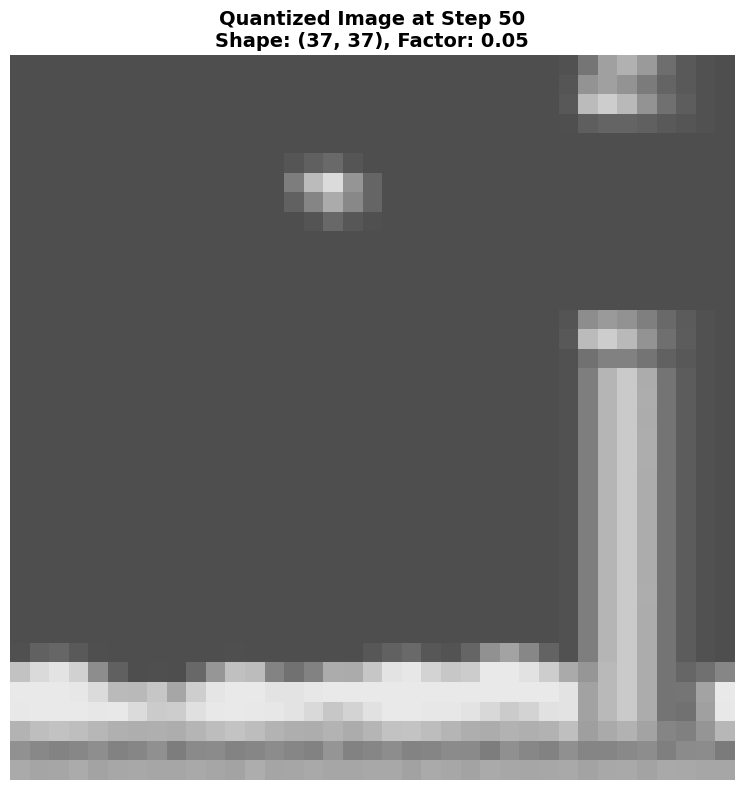

Quantized image shape: (37, 37)
Quantization factor: 0.05


In [24]:
# Show quantized image at step 50
env = gym.make("FlappyBird-v0", render_mode="human")
observation, _ = env.reset()
observation = np.asarray(observation, dtype=np.float32)

# Run until step 50
for step in range(50):
    # Flap every 5 steps
    action = 1 if step % 10 == 0 else 0
    observation, reward, terminated, truncated, _ = env.step(action)
    observation = np.asarray(observation, dtype=np.float32)
    
    if terminated or truncated:
        observation, _ = env.reset()
        observation = np.asarray(observation, dtype=np.float32)

# Process observation into quantized image at step 50
matrix_observations, _ = evaluator._process_observation(observation)
quantized_image = matrix_observations[0]

env.close()

# Display just the quantized image at step 50
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.imshow(quantized_image, cmap='gray', vmin=0, vmax=1)
ax.set_title(f"Quantized Image at Step 50\nShape: {quantized_image.shape}, Factor: {evaluator.quantization_factor}", 
             fontsize=14, fontweight='bold')
ax.axis('off')

plt.tight_layout()
plt.show()

print(f"Quantized image shape: {quantized_image.shape}")
print(f"Quantization factor: {evaluator.quantization_factor}")


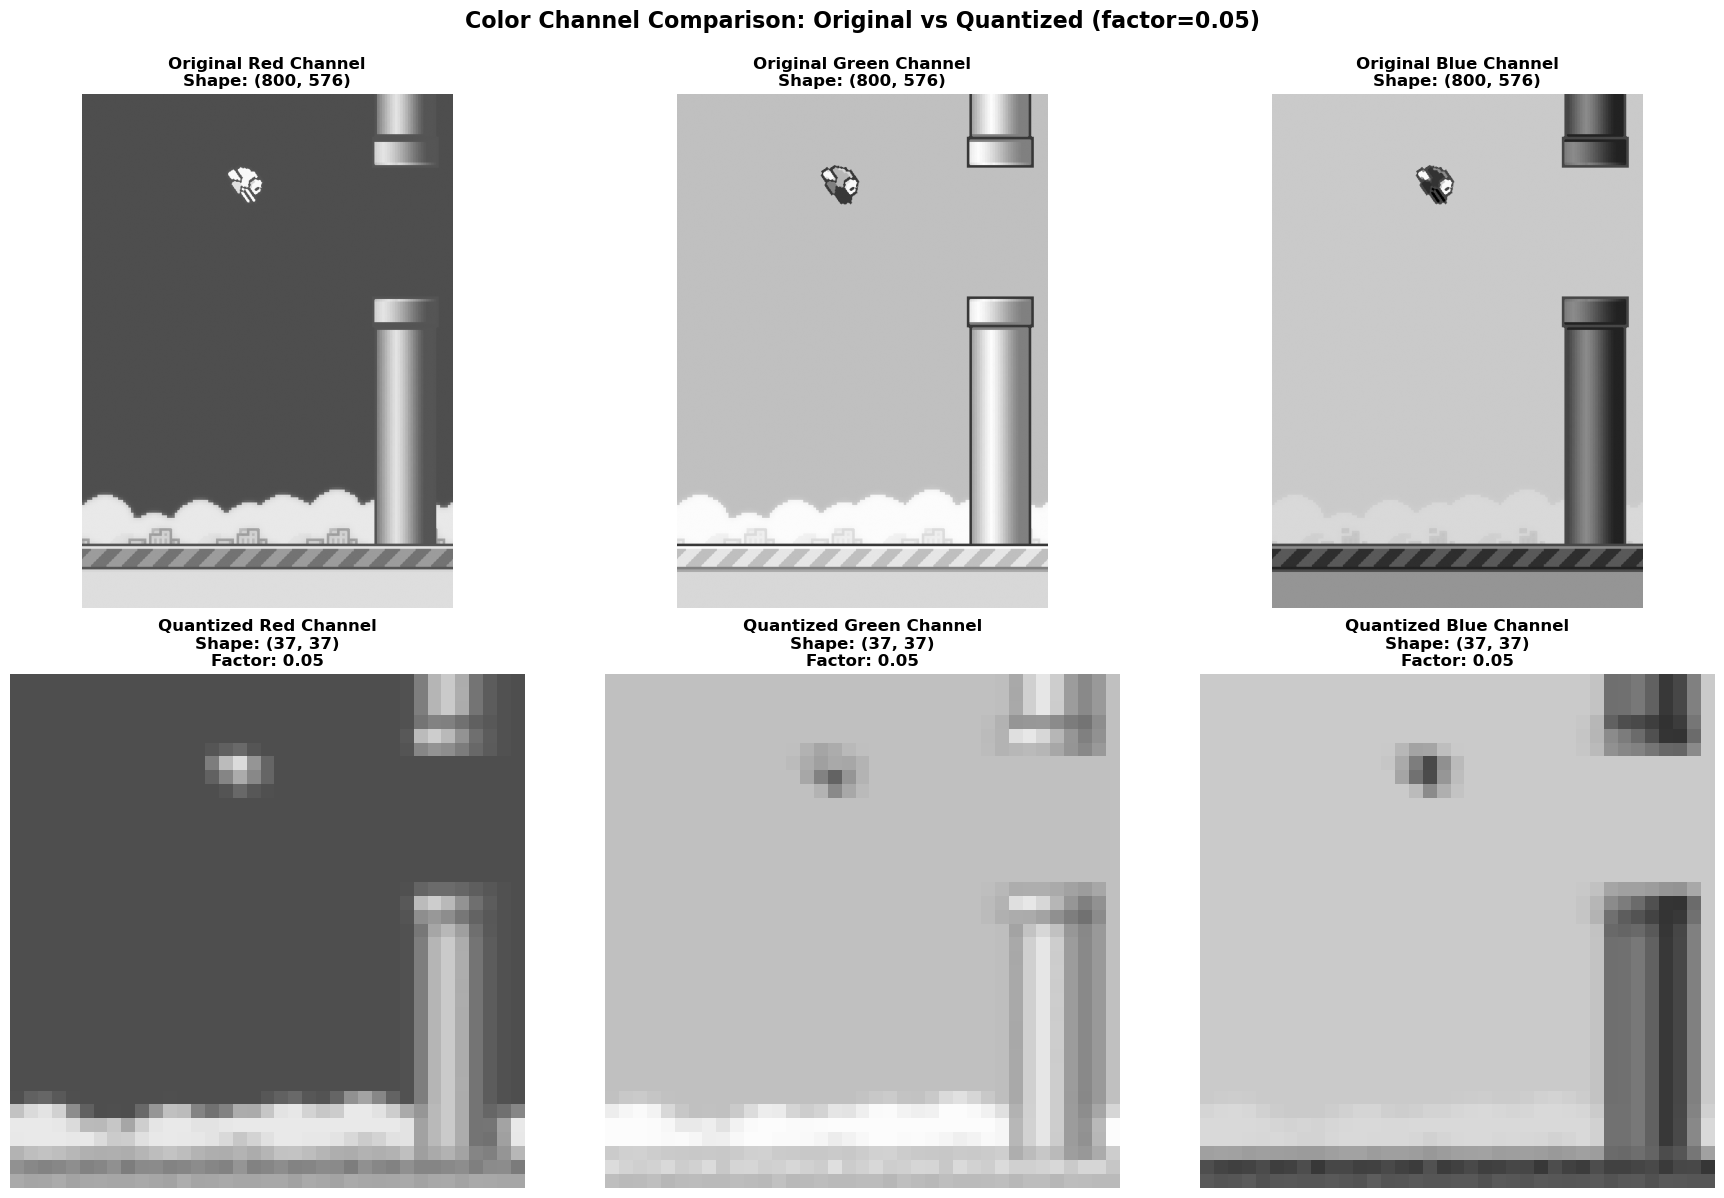

COLOR CHANNEL COMPARISON SUMMARY

Red Channel (R):
  Original shape: (800, 576)
  Quantized shape: (37, 37)
  Reduction factor: 21.62x

Green Channel (G):
  Original shape: (800, 576)
  Quantized shape: (37, 37)
  Reduction factor: 21.62x

Blue Channel (B):
  Original shape: (800, 576)
  Quantized shape: (37, 37)
  Reduction factor: 21.62x

Quantization factor: 0.05


In [25]:
# Compare all 3 color channels (R, G, B) with quantization
import matplotlib.pyplot as plt

# Get the same observation at step 50
env = gym.make("FlappyBird-v0", render_mode="human")
observation, _ = env.reset()
observation = np.asarray(observation, dtype=np.float32)

# Run until step 50
for step in range(50):
    action = 1 if step % 10 == 0 else 0
    observation, reward, terminated, truncated, _ = env.step(action)
    observation = np.asarray(observation, dtype=np.float32)
    
    if terminated or truncated:
        observation, _ = env.reset()
        observation = np.asarray(observation, dtype=np.float32)

# Capture the observation
test_observation = observation.copy()
env.close()

# Create evaluators for each color channel
quantization_factor = 0.05  # Same as in Cell 4
channels = [
    (0, 'R', 'Red'),
    (1, 'G', 'Green'),
    (2, 'B', 'Blue')
]

# Process each channel
results = []
for channel_idx, channel_code, channel_name in channels:
    config = FlappyBirdEvaluatorConfig(
        env_id="FlappyBird-v0",
        episodes=1,
        max_steps=500,
        output_register=7,
        render_mode=None,  # No rendering needed
        rng_seed=0,
        patch_strategy="quantized",
        color_channel=channel_idx,
        normalize=True,
        quantization_factor=quantization_factor,
        output_registers=[(MemoryType.SCALAR, 7)],
    )
    eval_channel = FlappyBirdEvaluator(config=config)
    
    # Get original channel and quantized version
    original_channel = eval_channel._extract_color_channel(test_observation)
    matrix_observations, _ = eval_channel._process_observation(test_observation)
    quantized_image = matrix_observations[0]
    
    results.append({
        'channel_idx': channel_idx,
        'channel_code': channel_code,
        'channel_name': channel_name,
        'original': original_channel,
        'quantized': quantized_image
    })
    
    eval_channel.close()

# Create comparison visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for idx, result in enumerate(results):
    # Top row: Original channels
    axes[0, idx].imshow(result['original'], cmap='gray', vmin=0, vmax=1)
    axes[0, idx].set_title(f"Original {result['channel_name']} Channel\nShape: {result['original'].shape}", 
                          fontsize=12, fontweight='bold')
    axes[0, idx].axis('off')
    
    # Bottom row: Quantized channels
    axes[1, idx].imshow(result['quantized'], cmap='gray', vmin=0, vmax=1)
    axes[1, idx].set_title(f"Quantized {result['channel_name']} Channel\nShape: {result['quantized'].shape}\nFactor: {quantization_factor}", 
                           fontsize=12, fontweight='bold')
    axes[1, idx].axis('off')

plt.suptitle(f"Color Channel Comparison: Original vs Quantized (factor={quantization_factor})", 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# Print summary
print("=" * 70)
print("COLOR CHANNEL COMPARISON SUMMARY")
print("=" * 70)
for result in results:
    print(f"\n{result['channel_name']} Channel ({result['channel_code']}):")
    print(f"  Original shape: {result['original'].shape}")
    print(f"  Quantized shape: {result['quantized'].shape}")
    print(f"  Reduction factor: {result['original'].shape[0] / result['quantized'].shape[0]:.2f}x")
print(f"\nQuantization factor: {quantization_factor}")
print("=" * 70)


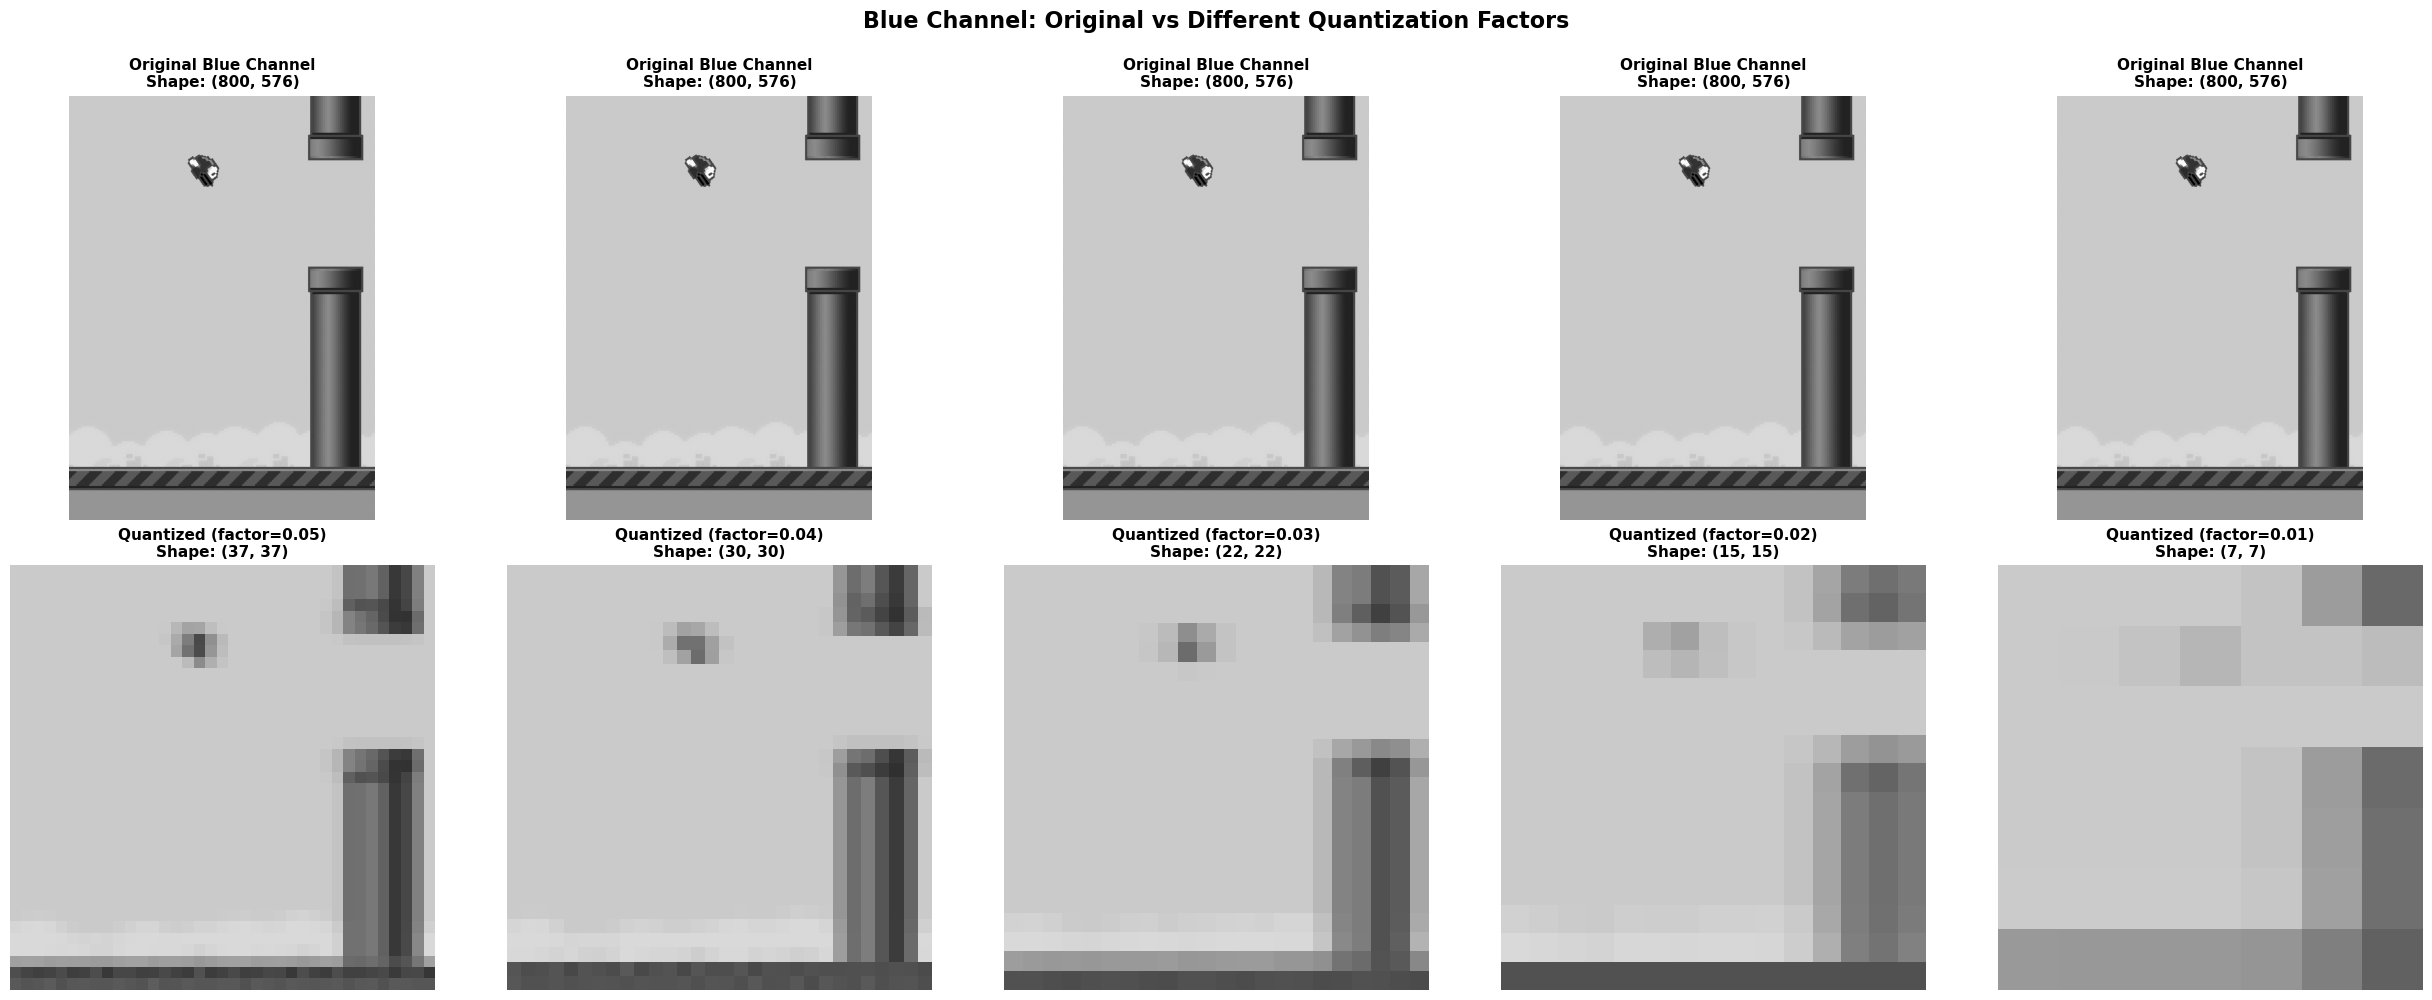

BLUE CHANNEL QUANTIZATION COMPARISON

Original Blue Channel:
  Shape: (800, 576)
  Total pixels: 460,800

Quantized Versions:

  Factor 0.05:
    Shape: (37, 37)
    Total pixels: 1,369
    Reduction: 21.6x (height) × 15.6x (width) = 336.6x total
    Compression: 99.7% size reduction

  Factor 0.04:
    Shape: (30, 30)
    Total pixels: 900
    Reduction: 26.7x (height) × 19.2x (width) = 512.0x total
    Compression: 99.8% size reduction

  Factor 0.03:
    Shape: (22, 22)
    Total pixels: 484
    Reduction: 36.4x (height) × 26.2x (width) = 952.1x total
    Compression: 99.9% size reduction

  Factor 0.02:
    Shape: (15, 15)
    Total pixels: 225
    Reduction: 53.3x (height) × 38.4x (width) = 2048.0x total
    Compression: 100.0% size reduction

  Factor 0.01:
    Shape: (7, 7)
    Total pixels: 49
    Reduction: 114.3x (height) × 82.3x (width) = 9404.1x total
    Compression: 100.0% size reduction


: 

In [ ]:
# Compare Blue Channel with different quantization factors (0.05 to 0.01, step 0.01)
import matplotlib.pyplot as plt

# Get the same observation at step 50
env = gym.make("FlappyBird-v0", render_mode="human")
observation, _ = env.reset()
observation = np.asarray(observation, dtype=np.float32)

# Run until step 50
for step in range(50):
    action = 1 if step % 10 == 0 else 0
    observation, reward, terminated, truncated, _ = env.step(action)
    observation = np.asarray(observation, dtype=np.float32)
    
    if terminated or truncated:
        observation, _ = env.reset()
        observation = np.asarray(observation, dtype=np.float32)

# Capture the observation
test_observation = observation.copy()
env.close()

# Blue channel (B = 2)
blue_channel_idx = 2

# Create evaluator to get original blue channel
config_original = FlappyBirdEvaluatorConfig(
    env_id="FlappyBird-v0",
    episodes=1,
    max_steps=500,
    output_register=7,
    render_mode=None,
    rng_seed=0,
    patch_strategy="quantized",
    color_channel=blue_channel_idx,
    normalize=True,
    quantization_factor=0.05,  # Dummy value, we just need to extract original channel
    output_registers=[(MemoryType.SCALAR, 7)],
)
eval_original = FlappyBirdEvaluator(config=config_original)
original_blue_channel = eval_original._extract_color_channel(test_observation)
eval_original.close()

# Test different quantization factors
quantization_factors = [0.05, 0.04, 0.03, 0.02, 0.01]
results = []

for qf in quantization_factors:
    config = FlappyBirdEvaluatorConfig(
        env_id="FlappyBird-v0",
        episodes=1,
        max_steps=500,
        output_register=7,
        render_mode=None,
        rng_seed=0,
        patch_strategy="quantized",
        color_channel=blue_channel_idx,
        normalize=True,
        quantization_factor=qf,
        output_registers=[(MemoryType.SCALAR, 7)],
    )
    eval_qf = FlappyBirdEvaluator(config=config)
    
    # Get quantized version
    matrix_observations, _ = eval_qf._process_observation(test_observation)
    quantized_image = matrix_observations[0]
    
    results.append({
        'factor': qf,
        'quantized': quantized_image
    })
    
    eval_qf.close()

# Create comparison visualization
num_factors = len(quantization_factors)
fig, axes = plt.subplots(2, num_factors, figsize=(5 * num_factors, 10))

# Top row: Original blue channel (same for all)
for idx in range(num_factors):
    axes[0, idx].imshow(original_blue_channel, cmap='gray', vmin=0, vmax=1)
    axes[0, idx].set_title(f"Original Blue Channel\nShape: {original_blue_channel.shape}", 
                          fontsize=11, fontweight='bold')
    axes[0, idx].axis('off')

# Bottom row: Quantized versions with different factors
for idx, result in enumerate(results):
    axes[1, idx].imshow(result['quantized'], cmap='gray', vmin=0, vmax=1)
    axes[1, idx].set_title(f"Quantized (factor={result['factor']})\nShape: {result['quantized'].shape}", 
                          fontsize=11, fontweight='bold')
    axes[1, idx].axis('off')

plt.suptitle("Blue Channel: Original vs Different Quantization Factors", 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# Print detailed summary
print("=" * 80)
print("BLUE CHANNEL QUANTIZATION COMPARISON")
print("=" * 80)
print(f"\nOriginal Blue Channel:")
print(f"  Shape: {original_blue_channel.shape}")
print(f"  Total pixels: {original_blue_channel.size:,}")

print(f"\nQuantized Versions:")
for result in results:
    qf = result['factor']
    quantized = result['quantized']
    reduction_h = original_blue_channel.shape[0] / quantized.shape[0]
    reduction_w = original_blue_channel.shape[1] / quantized.shape[1]
    total_reduction = original_blue_channel.size / quantized.size
    
    print(f"\n  Factor {qf:.2f}:")
    print(f"    Shape: {quantized.shape}")
    print(f"    Total pixels: {quantized.size:,}")
    print(f"    Reduction: {reduction_h:.1f}x (height) × {reduction_w:.1f}x (width) = {total_reduction:.1f}x total")
    print(f"    Compression: {100 * (1 - quantized.size / original_blue_channel.size):.1f}% size reduction")

print("=" * 80)


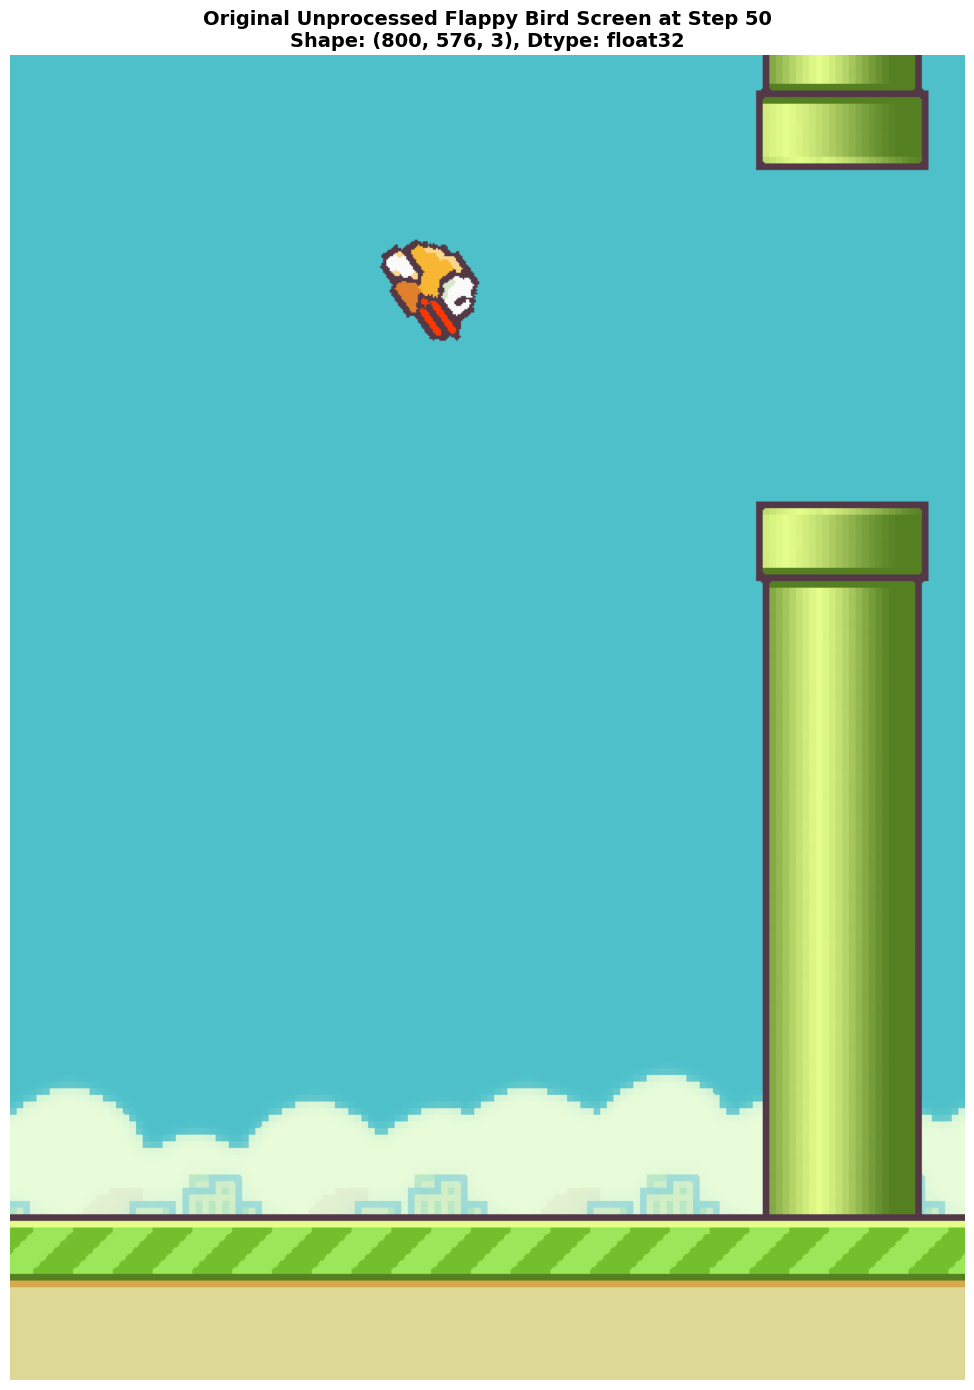

Original observation shape: (800, 576, 3)
Original observation dtype: float32
Original observation value range: [0.0, 253.0]


: 

In [ ]:
# Capture and display the original unprocessed Flappy Bird screen at step 50
env = gym.make("FlappyBird-v0", render_mode="human")
observation, _ = env.reset()
observation = np.asarray(observation, dtype=np.float32)

# Run until step 50
for step in range(50):
    # Flap every 5 steps
    action = 1 if step % 10 == 0 else 0
    observation, reward, terminated, truncated, _ = env.step(action)
    observation = np.asarray(observation, dtype=np.float32)
    
    if terminated or truncated:
        observation, _ = env.reset()
        observation = np.asarray(observation, dtype=np.float32)

# Capture the original unprocessed observation
original_observation = observation.copy()

env.close()

# Display the original unprocessed Flappy Bird screen
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(10, 14))
# Convert to uint8 for display (observation is float32 in range 0-255)
ax.imshow(original_observation.astype(np.uint8))
ax.set_title(f"Original Unprocessed Flappy Bird Screen at Step 50\nShape: {original_observation.shape}, Dtype: {original_observation.dtype}", 
             fontsize=14, fontweight='bold')
ax.axis('off')

plt.tight_layout()
plt.show()

print(f"Original observation shape: {original_observation.shape}")
print(f"Original observation dtype: {original_observation.dtype}")
print(f"Original observation value range: [{original_observation.min():.1f}, {original_observation.max():.1f}]")



In [ ]:
# # Visualize 700x576 crop (removing top 50 and bottom 50 pixels)
# env = gym.make("FlappyBird-v0", render_mode="human")
# test_observation, info = env.reset()
# test_observation = np.asarray(test_observation, dtype=np.float32)

# # Original image dimensions
# h, w = test_observation.shape[:2]  # 800x576
# print(f"Original image: {h}x{w}")

# # Crop parameters: remove top 50 and bottom 50 pixels
# crop_top = 50
# crop_bottom = 50
# new_height = h - crop_top - crop_bottom  # 800 - 50 - 50 = 700
# new_width = w  # Keep full width: 576

# print(f"\nCrop configuration:")
# print(f"  Remove top: {crop_top} pixels")
# print(f"  Remove bottom: {crop_bottom} pixels")
# print(f"  New dimensions: {new_height}x{new_width}")
# print(f"  Lost pixels: {crop_top + crop_bottom} rows ({100 * (crop_top + crop_bottom) / h:.1f}% of height)")

# # Extract color channel (green)
# single_channel = test_observation[:, :, 1].astype(np.float32) / 255.0

# # Create cropped version (700x576)
# cropped_700 = single_channel[crop_top:h-crop_bottom, :]

# # Get pipe information if available
# pipe_info = []
# if hasattr(env, 'env') and hasattr(env.env, 'pipes'):
#     pipes = env.env.pipes
#     for pipe in pipes:
#         pipe_x = getattr(pipe, 'x', 0)
#         pipe_top = getattr(pipe, 'top', 0)
#         pipe_bottom = getattr(pipe, 'bottom', 0)
#         pipe_info.append({
#             'x': pipe_x,
#             'top': pipe_top,
#             'bottom': pipe_bottom,
#             'visible_x': 0 <= pipe_x < w,
#             'visible_y': crop_top <= pipe_top < (h - crop_bottom) or crop_top <= pipe_bottom < (h - crop_bottom)
#         })

# # Visualize
# import matplotlib.pyplot as plt
# import matplotlib.patches as patches

# fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# # 1. Original image with crop boundaries
# ax1 = axes[0, 0]
# ax1.imshow(test_observation.astype(np.uint8))
# # Draw crop boundaries
# rect = patches.Rectangle((0, crop_top), w, new_height, 
#                         linewidth=3, edgecolor='lime', facecolor='none', linestyle='--')
# ax1.add_patch(rect)
# # Draw lost regions
# lost_top = patches.Rectangle((0, 0), w, crop_top, 
#                              linewidth=2, edgecolor='red', facecolor='red', alpha=0.3)
# lost_bottom = patches.Rectangle((0, h - crop_bottom), w, crop_bottom, 
#                                linewidth=2, edgecolor='red', facecolor='red', alpha=0.3)
# ax1.add_patch(lost_top)
# ax1.add_patch(lost_bottom)
# ax1.set_title(f"Original 800x576 with Crop Boundaries\nGreen dashed: kept region, Red: lost regions", 
#               fontsize=12, fontweight='bold')
# ax1.axis('off')

# # Mark pipe positions if available
# if pipe_info:
#     for pipe in pipe_info:
#         pipe_x = pipe['x']
#         if 0 <= pipe_x < w:
#             color = 'yellow' if pipe['visible_x'] and pipe['visible_y'] else 'red'
#             ax1.axvline(x=pipe_x, color=color, linewidth=2, linestyle=':', alpha=0.8)
#             if pipe['visible_x']:
#                 ax1.text(pipe_x, 100, f"Pipe\nx={pipe_x}", color=color, fontsize=8, 
#                         ha='center', bbox=dict(boxstyle='round', facecolor='black', alpha=0.7))

# # 2. What gets cropped out (top)
# ax2 = axes[0, 1]
# top_cropped = test_observation[:crop_top, :]
# if top_cropped.size > 0:
#     ax2.imshow(top_cropped.astype(np.uint8))
#     ax2.set_title(f"Lost: Top {crop_top} rows", 
#                   fontsize=12, fontweight='bold', color='red')
# else:
#     ax2.text(0.5, 0.5, "No top crop", ha='center', va='center', fontsize=14)
# ax2.axis('off')

# # 3. What gets cropped out (bottom)
# ax3 = axes[0, 2]
# bottom_cropped = test_observation[h-crop_bottom:, :]
# if bottom_cropped.size > 0:
#     ax3.imshow(bottom_cropped.astype(np.uint8))
#     ax3.set_title(f"Lost: Bottom {crop_bottom} rows", 
#                   fontsize=12, fontweight='bold', color='red')
# else:
#     ax3.text(0.5, 0.5, "No bottom crop", ha='center', va='center', fontsize=14)
# ax3.axis('off')

# # 4. The cropped version (what we keep)
# ax4 = axes[1, 0]
# ax4.imshow(cropped_700, cmap='gray', vmin=0, vmax=1)
# ax4.set_title(f"Kept: Cropped 700x576 region\nRows {crop_top} to {h-crop_bottom}", 
#               fontsize=12, fontweight='bold', color='green')
# ax4.axis('off')

# # Mark pipe positions in cropped view
# if pipe_info:
#     for pipe in pipe_info:
#         pipe_x = pipe['x']
#         if 0 <= pipe_x < w and pipe['visible_y']:
#             # Adjust y coordinates for cropped view
#             adjusted_top = pipe['top'] - crop_top
#             adjusted_bottom = pipe['bottom'] - crop_top
#             if 0 <= adjusted_top < new_height or 0 <= adjusted_bottom < new_height:
#                 ax4.axvline(x=pipe_x, color='yellow', linewidth=2, linestyle=':', alpha=0.8)
#                 ax4.text(pipe_x, 50, f"Pipe\nx={pipe_x}", color='yellow', fontsize=8, 
#                         ha='center', bbox=dict(boxstyle='round', facecolor='black', alpha=0.7))

# # 5. Show patches that would be extracted (with patch_size=200)
# ax5 = axes[1, 1]
# # For 700x576: we can't cleanly divide 700 by 200 (700/200 = 3.5)
# # Let's show what patches we'd get with patch_size=175: 700/175 = 4, so 4x2 = 8 patches
# # Or with patch_size=140: 700/140 = 5, 576/144 = 4, so 5x4 = 20 patches
# patch_size_700 = 140
# grid_h = new_height // patch_size_700  # 700/140 = 5
# grid_w = new_width // patch_size_700   # 576/140 = 4 (truncated, but let's use 144 for width)
# patch_size_w = 144
# grid_w = new_width // patch_size_w  # 576/144 = 4

# # Extract patches
# patches_700 = []
# for i in range(grid_h):
#     for j in range(grid_w):
#         y0 = i * patch_size_700
#         y1 = min(y0 + patch_size_700, new_height)
#         x0 = j * patch_size_w
#         x1 = min(x0 + patch_size_w, new_width)
#         patch = np.zeros((patch_size_700, patch_size_w), dtype=np.float32)
#         patch[:y1-y0, :x1-x0] = cropped_700[y0:y1, x0:x1]
#         patches_700.append(patch)

# # Create composite
# composite_700 = np.zeros((grid_h * patch_size_700, grid_w * patch_size_w), dtype=np.float32)
# for idx, patch in enumerate(patches_700):
#     i, j = idx // grid_w, idx % grid_w
#     composite_700[i*patch_size_700:(i+1)*patch_size_700, 
#                   j*patch_size_w:(j+1)*patch_size_w] = patch

# ax5.imshow(composite_700, cmap='gray', vmin=0, vmax=1)
# ax5.set_title(f"700x576 patches\n{grid_h}x{grid_w} grid = {len(patches_700)} patches\n({patch_size_700}x{patch_size_w} each)", 
#               fontsize=12, fontweight='bold')
# ax5.axis('off')
# # 6. Comparison: Original vs Cropped side by side
# ax6 = axes[1, 2]
# comparison = np.hstack([
#     single_channel,
#     np.ones((h, 10), dtype=np.float32),  # Separator
#     np.vstack([
#         np.zeros((crop_top, new_width), dtype=np.float32),
#         cropped_700,
#         np.zeros((crop_bottom, new_width), dtype=np.float32)
#     ])
# ])
# ax6.imshow(comparison, cmap='gray', vmin=0, vmax=1)
# ax6.set_title(f"Comparison: Original (left) vs Cropped (right)\nOriginal: {h}x{w}, Cropped: {new_height}x{new_width}", 
#               fontsize=12, fontweight='bold')
# ax6.axis('off')

# plt.tight_layout()
# plt.show()

# # Summary
# print(f"\n{'='*60}")
# print("SUMMARY: 700x576 Crop")
# print(f"{'='*60}")
# print(f"Original dimensions: {h}x{w}")
# print(f"Cropped dimensions: {new_height}x{new_width}")
# print(f"Lost: {crop_top} rows (top) + {crop_bottom} rows (bottom) = {crop_top + crop_bottom} rows")
# print(f"Lost percentage: {100 * (crop_top + crop_bottom) / h:.1f}% of height")

# if pipe_info:
#     visible_pipes = sum(1 for p in pipe_info if p['visible_x'] and p['visible_y'])
#     total_pipes = len(pipe_info)
#     print(f"\nPipe visibility:")
#     print(f"  Total pipes: {total_pipes}")
#     print(f"  Fully visible: {visible_pipes} ({100*visible_pipes/total_pipes:.1f}%)")
#     if visible_pipes < total_pipes:
#         print(f"  ⚠️  {total_pipes - visible_pipes} pipes partially or fully outside crop region")
#     else:
#         print(f"  ✓ All pipes are visible in cropped region")

# print(f"\nPatch extraction (with patch_size=140x144):")
# print(f"  Grid: {grid_h}x{grid_w} = {len(patches_700)} patches")
# print(f"  Each patch: {patch_size_700}x{patch_size_w}")

# env.close()


In [ ]:
# Small Evolutionary Test
# Set up evaluator for evolution (no rendering for speed)
rng = np.random.default_rng(5)

evolution_evaluator_config = FlappyBirdEvaluatorConfig(
    env_id="FlappyBird-v0",
    episodes=5,  # Fewer episodes for faster evolution
    max_steps=500,  # Shorter episodes
    output_register=0,
    render_mode="human",  # No rendering for speed
    rng_seed=5,  # Use seed instead of rng object
    
    patch_strategy="quantized",
    color_channel=1,
    normalize=True,
    quantization_factor=0.05,
    output_registers=[(MemoryType.SCALAR, 0)],  # For effective program calculation
)

evolution_evaluator = FlappyBirdEvaluator(config=evolution_evaluator_config)

# Calculate actual number of patches for "full" strategy
# With patch_size=200 on 800x800 image: 800/200 = 4, so 4x4 = 16 patches
actual_num_patches = 1  # This matches what we saw in Cell 3

# Update memory config to match actual patches
memory_cfg_evolution = MemoryConfig(
    n_scalar=8,
    n_vector=8,
    n_matrix=8,
    n_obs_scalar=0,
    n_obs_vector=0,
    n_obs_matrix=1,  # Match actual number of patches
    vector_size=37,
    matrix_shape=(37, 37),
)


all_ops = AUTOML_ALL_OPS + CV_ALL_OPS

# Create instruction set with updated config
instruction_set_evolution = InstructionSet([op() for op in all_ops], memory_cfg_evolution)
operators_evolution = GeneticOperators(instruction_set_evolution, rng)

# Small population for quick test
pop_config = PopulationConfig(
    size=100,  # Small population
    program_length=(1, 10),  # Short to medium programs
    elitism=50,  # Keep best individual
    max_program_length=250,
)
# pop_config = PopulationConfig(
#     size=10,  # Small population
#     program_length=(1, 10),  # Short to medium programs
#     elitism=5,  # Keep best individual
#     max_program_length=250,
# )
# Create population
population = Population(
    pop_config,
    instruction_set_evolution,
    memory_cfg_evolution,
    operators=operators_evolution,
    rng=rng,
)
population.initialize_random(mutate_constants=True)

print("Evolution Setup Complete!")
print(f"Population size: {pop_config.size}")
print(f"Program length range: {pop_config.program_length}")
print(f"Episodes per evaluation: {evolution_evaluator.episodes}")
print(f"Max steps per episode: {evolution_evaluator.max_steps}")
print(f"Number of patches: {actual_num_patches}")


NameError: name 'np' is not defined

In [ ]:
# Run evolutionary loop
evolution_config = EvolutionConfig(
    max_generations=100,  # Small number for quick test
    mutation_threshold=0.9,
    constant_mutation_rate=0.1,
    verbose=True,
    checkpoint_path="checkpoints/best_population.pkl",
    stats_log_dir= "stats_log"
)

engine = EvolutionEngine(
    population=population,
    operators=operators_evolution,
    evaluator=evolution_evaluator,
    config=evolution_config,
    rng=rng,
)

print("Starting evolution...")
print("=" * 60)
final_population = engine.run()
print("=" * 60)
print("\nEvolution complete!")

# Close evaluator
evolution_evaluator.close()


Starting evolution...
Evaluated 10/100 individuals
Evaluated 20/100 individuals
Evaluated 30/100 individuals
Evaluated 40/100 individuals
Evaluated 50/100 individuals
Evaluated 60/100 individuals
Evaluated 70/100 individuals
Evaluated 80/100 individuals
Evaluated 90/100 individuals
Evaluated 100/100 individuals
  → Initialized best_ever (fitness: 0.0340, gen: 0)
Best agent: fitness=0.0340, effective_code_rate=0.000 (0/7)
✓ Checkpoint saved: generation=0, fitness=0.0340 -> checkpoints/best_population.pkl

=== Generation 0 ===
Generation 0 | Population size 100
Min: 0.020, Mean: 0.028, Max: 0.034, Std: 0.007
Length mean 5.4, std 2.8
Best ever fitness 0.034 at generation 0
Evaluated 10/100 individuals
Evaluated 20/100 individuals
Evaluated 30/100 individuals
Evaluated 40/100 individuals
Evaluated 50/100 individuals
Evaluated 60/100 individuals
Evaluated 70/100 individuals
Evaluated 80/100 individuals
Evaluated 90/100 individuals
Evaluated 100/100 individuals
Best agent: fitness=0.0340, ef


BEST AGENT HISTORY (Fitness & Effective Code Rate)
Gen   Fitness      Eff. Code Rate     Eff. Length     Total Length   
------------------------------------------------------------
0     0.0340       0.125              1               8              
1     0.0340       0.125              1               8              
2     0.0340       0.125              1               8              
3     0.0340       0.125              1               8              
4     0.0340       0.125              1               8              
5     0.0340       0.125              1               8              
6     0.0340       0.125              1               8              
7     0.0340       0.125              1               8              
8     0.0340       0.125              1               8              
9     0.0340       0.125              1               8              


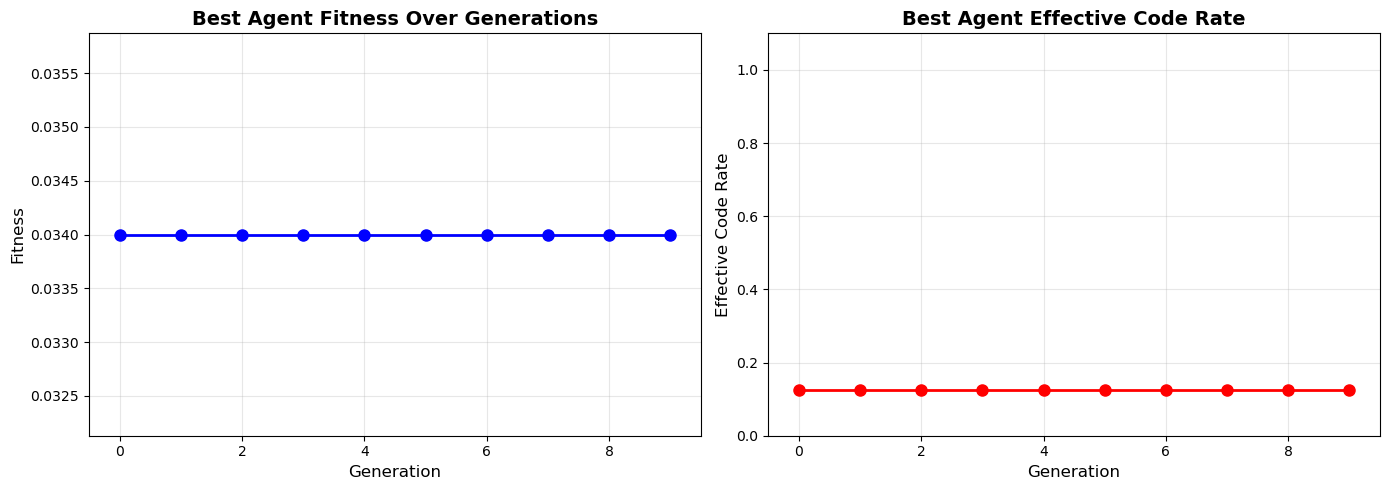


Best overall fitness: 0.0340 (Generation 0)
Final effective code rate: 0.125


In [ ]:
# Display best agent history
print("\n" + "=" * 60)
print("BEST AGENT HISTORY (Fitness & Effective Code Rate)")
print("=" * 60)
print(f"{'Gen':<5} {'Fitness':<12} {'Eff. Code Rate':<18} {'Eff. Length':<15} {'Total Length':<15}")
print("-" * 60)

for info in engine.best_agent_history:
    print(f"{info.generation:<5} {info.fitness:<12.4f} {info.effective_code_rate:<18.3f} "
          f"{info.effective_length:<15} {info.total_length:<15}")

# Plot fitness and effective code rate over generations
import matplotlib.pyplot as plt

if len(engine.best_agent_history) > 0:
    generations = [info.generation for info in engine.best_agent_history]
    fitnesses = [info.fitness for info in engine.best_agent_history]
    code_rates = [info.effective_code_rate for info in engine.best_agent_history]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot fitness
    ax1.plot(generations, fitnesses, 'b-o', linewidth=2, markersize=8)
    ax1.set_xlabel('Generation', fontsize=12)
    ax1.set_ylabel('Fitness', fontsize=12)
    ax1.set_title('Best Agent Fitness Over Generations', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(-0.5, max(generations) + 0.5)
    
    # Plot effective code rate
    ax2.plot(generations, code_rates, 'r-o', linewidth=2, markersize=8)
    ax2.set_xlabel('Generation', fontsize=12)
    ax2.set_ylabel('Effective Code Rate', fontsize=12)
    ax2.set_title('Best Agent Effective Code Rate', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim(0, 1.1)
    ax2.set_xlim(-0.5, max(generations) + 0.5)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nBest overall fitness: {max(fitnesses):.4f} (Generation {generations[fitnesses.index(max(fitnesses))]})")
    print(f"Final effective code rate: {code_rates[-1]:.3f}")


In [ ]:
# ckpt = EvolutionEngine.load_checkpoint("checkpoints/best_population.pkl")
# population = ckpt["population"]
# Visualize the best evolved agent

# Use best_ever if available, otherwise get the best from current population
if population.best_ever is not None:
    best_agent = population.best_ever
    print(f"Using best_ever agent (fitness: {best_agent.fitness:.4f})")
    print(f"Best ever generation: {population.best_ever_generation}")
else:
    # Fallback: get best from current population
    best_agent = population.get_best()
    print(f"best_ever not set, using current best agent (fitness: {best_agent.fitness:.4f})")

# Print best agent details
print("\n" + "="*70)
print("BEST AGENT DETAILS")
print("="*70)
print(f"Fitness: {best_agent.fitness:.4f}")
print(f"Program length: {len(best_agent.program)}")
print(f"Age: {best_agent.age}")

# Get output registers for effective length
output_registers = getattr(evolution_evaluator, "output_registers", None)
if output_registers:
    effective_length = best_agent.get_effective_length(output_registers)
    effective_ratio = effective_length / len(best_agent.program) if len(best_agent.program) > 0 else 0.0
    print(f"Effective length: {effective_length}")
    print(f"Effective code rate: {effective_ratio:.3f}")
print(output_registers)
print("\nInstructions:")
for i, instr in enumerate(best_agent.program.instructions):
    print(f"  {i:3d}: {instr}")
print("="*70)

print("\nLaunching visualization for the best agent...")
viz_evaluator_config = FlappyBirdEvaluatorConfig(
    env_id="FlappyBird-v0",
    episodes=1,              # just watch one run
    max_steps=500,
    output_register=evolution_evaluator.output_register,
    render_mode="human",     # opens the pygame window
    rng_seed=0,  # Use seed instead of rng object
    patch_strategy=evolution_evaluator.patch_strategy,
    color_channel=evolution_evaluator.color_channel,
    normalize=evolution_evaluator.normalize,
    quantization_factor=evolution_evaluator.quantization_factor,
    output_registers=[(MemoryType.SCALAR, evolution_evaluator.output_register)],  # For effective program calculation
)

viz_evaluator = FlappyBirdEvaluator(config=viz_evaluator_config)

fitness = viz_evaluator.evaluate(best_agent)
print(f"Best agent fitness during visualization: {fitness:.3f}")

viz_evaluator.close()


Using best_ever agent (fitness: 0.4876)
Best ever generation: 68

BEST AGENT DETAILS
Fitness: 0.4876
Program length: 12
Age: 0
Effective length: 1
Effective code rate: 0.083
[(<MemoryType.SCALAR: 'scalar'>, 0)]

Instructions:
    0: scalar[2] = automl_scalar_max(obs_scalar[3514], obs_scalar[9665])
    1: scalar[4] = automl_vector_std(obs_vector[240])
    2: scalar[3] = automl_scalar_div(obs_scalar[9381], scalar[1494])
    3: scalar[0] = automl_scalar_gaussian(scalar[4590], scalar[332])
    4: matrix[1] = automl_vector_broadcast_axis1(obs_vector[4786])
    5: scalar[3] = automl_matrix_mean(matrix[1149])
    6: scalar[1] = automl_scalar_exp(scalar[2757])
    7: matrix[7] = automl_vector_broadcast_axis1(vector[1258])
    8: scalar[3] = automl_vector_mean(vector[4279])
    9: scalar[6] = automl_vector_mean(vector[2463])
   10: scalar[5] = automl_scalar_mul(scalar[6003], obs_scalar[519])
   11: scalar[5] = automl_scalar_max(obs_scalar[3586], scalar[4187])

Launching visualization for the be